<table style="background-color: transparent;">
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%" align="center"><font size="7" color="#6366F1">Computación Cuántica</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">Temas Selectos de Ingeniería en Computación III</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="4" color="black">2027-1</font></td>
    </tr>
    <tr style="background-color: transparent; text-align:center;">
        <td width="100%"><font size="6" color="#6366F1">Laboratorio de PennyLane 1: Introducción</font></td>
    </tr>
</table>

---
<h3>Autores:</h3>

<h4>
- Naomi Reyes Granados<br>
- Sebastián González Juárez<br>
- Owen Charbel Sam Ramírez<br>
- [Nombre completo alumno 2]
</h4>

<p>
Este notebook está adaptado del material desarrollado originalmente por
<b>Claudia Zendejas Morales</b>, el cual constituye la base principal de este
notebook. Sobre dicho material se realizaron modificaciones, ampliaciones y
adaptaciones para su uso en esta clase.
</p>

---

# Introducción a PennyLane

PennyLane es una librería de Python orientada al desarrollo de aplicaciones de computación cuántica. Además de permitir la creación y ejecución de circuitos cuánticos, está diseñada para combinar estos procesos con herramientas de computación clásica, lo que permite desarrollar modelos híbridos. Entre sus principales áreas de aplicación se encuentran el machine learning cuántico y la química cuántica.

Uno de sus campos de aplicación es la química cuántica y el estudio de materiales. Un ejemplo se encuentra en el trabajo de Anselmetti et al. (2021), en el que participaron investigadores de Covestro, la Universidad de Colonia y QC Ware. En este trabajo se estudia el uso del algoritmo Variational Quantum Eigensolver (VQE) para la simulación de sistemas fermiónicos, como los que aparecen al estudiar la estructura electrónica de moléculas. Este tipo de aplicaciones permite emplear algoritmos cuánticos para abordar problemas relacionados con la simulación de moléculas y materiales.

Otra de sus aplicaciones se encuentra en el machine learning cuántico. PennyLane puede utilizarse para desarrollar modelos que combinan técnicas de aprendizaje automático con circuitos cuánticos. Un ejemplo es la implementación del algoritmo Quantum Variational Rewinding (QVR) para la detección de anomalías en series temporales. Este método utiliza datos considerados normales para entrenar un modelo y posteriormente identificar comportamientos anómalos en nuevos datos.

PennyLane también cuenta con herramientas para la mitigación de errores en circuitos cuánticos. Debido a que el hardware cuántico actual está sujeto a ruido, los resultados obtenidos pueden diferir de los valores ideales. Mediante su integración con Mitiq es posible aplicar técnicas como Zero-Noise Extrapolation (ZNE), que buscan disminuir el efecto de este ruido y obtener estimaciones más cercanas al comportamiento ideal del circuito.

Por último, PennyLane puede utilizarse para la simulación de circuitos cuánticos mediante hardware clásico de alto rendimiento. A través del simulador lightning.gpu y su integración con NVIDIA cuQuantum, es posible aprovechar el procesamiento mediante GPU para acelerar las operaciones requeridas durante las simulaciones. Esto permite reducir los tiempos de ejecución de simulaciones grandes en comparación con el uso exclusivo de CPU.

- Documentación oficial de PennyLane: https://docs.pennylane.ai/en/stable/
- Química cuántica y VQE: https://iopscience.iop.org/article/10.1088/1367-2630/ac2cb3
- Machine learning cuántico: https://iopscience.iop.org/article/10.1088/1367-2630/ac2cb3
- Mitigación de errores: https://pennylane.ai/blog/2021/11/error-mitigation-with-mitiq-and-pennylane/
- Simulación de circuitos cuánticos con GPU: https://pennylane.ai/blog/2022/07/lightning-fast-simulations-with-pennylane-and-the-nvidia-cuquantum-sdk/

Antes de comenzar, instalaremos PennyLane y las bibliotecas necesarias para ejecutar y visualizar los circuitos cuánticos en Google Colab.

In [ ]:
!pip install pennylane matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 74.8 MB/s eta 0:00:00


Después de instalar las bibliotecas necesarias, las importamos para utilizarlas a lo largo del laboratorio.

In [ ]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# 1. Representación de los qubits: PennyLane

En PennyLane los qubits se identifican mediante `wires`. Un `wire` funciona como un identificador que permite indicar sobre qué qubit se aplicará una operación.

Para trabajar con estos qubits debemos definir un dispositivo mediante `qml.device`. En este laboratorio utilizaremos `default.qubit`, un simulador de qubits incluido en PennyLane.

In [ ]:
# Creamos un dispositivo simulado con 1 qubit
dev = qml.device("default.qubit", wires=1)

In [ ]:
# Mostrar los wires disponibles en el dispositivo
print(dev.wires)

Wires([0])


In [ ]:
# Creamos un dispositivo con un wire identificado como "qreg"
dev_named = qml.device("default.qubit", wires=["qreg"])

print(dev_named.wires)

Wires(['qreg'])


# 2. Circuito Cuántico

Veamos cómo utilizar el qubit que definimos anteriormente dentro de un circuito.

En PennyLane un circuito se construye mediante una función de Python. Para indicar sobre qué dispositivo se ejecutará, la función se convierte en un `QNode` mediante `@qml.qnode(dev)`.

En este primer ejemplo no aplicaremos ninguna compuerta; únicamente observaremos el estado del qubit.

In [ ]:
# Creamos un circuito cuántico asociado al dispositivo dev
@qml.qnode(dev)           # @qml.qnode(dev) conecta el circuito con el dispositivo dev
def circuit():            # def circuit(): define el circuito
    return qml.state()    # qml.state() permite obtener el estado cuántico al finalizar el circuito.

Ahora podemos ejecutarlo:

In [ ]:
# Ejecutamos el circuito
estado = circuit()

print(estado)

[1.+0.j 0.+0.j]


Esto corresponde al estado inicial $|0\rangle$.

En el siguiente ejemplo trabajaremos con un circuito de 3 qubits. En PennyLane, para trabajar con más de un qubit, basta con indicar la cantidad de `wires` al crear el dispositivo.

In [ ]:
# Creamos un dispositivo simulado con 3 qubits
dev3 = qml.device("default.qubit", wires=3)

# Mostramos los wires disponibles
print(dev3.wires)

Wires([0, 1, 2])


El dispositivo contiene ahora 3 qubits, identificados mediante los `wires` `0`, `1` y `2`. A diferencia de Qiskit, en PennyLane no se definen bits clásicos al crear el circuito; las mediciones se especifican directamente como parte de la salida del `QNode`.

En el siguiente ejemplo aplicaremos una compuerta Hadamard al qubit `0`, seguida de dos compuertas CNOT. Finalmente, obtendremos las probabilidades de medición de los qubits `0` y `2`.

In [ ]:
# Creamos un circuito cuántico asociado al dispositivo dev3
@qml.qnode(dev3)
def circ():

    qml.Hadamard(wires=0)        # aplicar compuerta H al qubit 0

    qml.CNOT(wires=[0, 1])       # aplicar compuerta CNOT a los qubits 0 y 1

    qml.CNOT(wires=[0, 2])       # aplicar compuerta CNOT a los qubits 0 y 2

    return qml.probs(wires=[0, 2])  # obtener probabilidades de medición

Podemos ejecutar el circuito para obtener las probabilidades asociadas a las mediciones de los qubits `0` y `2`.

In [ ]:
resultado = circ()

print(resultado)

[0.5 0.  0.  0.5]


Finalmente, podemos mostrar la representación gráfica del circuito:

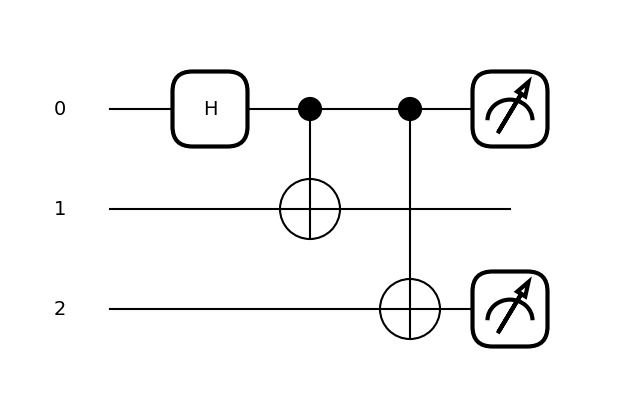

In [ ]:
# Mostrar la representación gráfica del circuito
qml.draw_mpl(circ)()
plt.show()

## Orden de los qubits

En el circuito anterior se tienen 3 qubits, identificados mediante los `wires` `0`, `1` y `2`. Al relacionarlos con las expresiones matemáticas, debemos considerar la convención utilizada por PennyLane.

Para un sistema de tres qubits, PennyLane utiliza el orden

$$
|q_0q_1q_2\rangle = |000\rangle
$$

donde el qubit asociado al `wire` `0` aparece primero.

## Estilos de los circuitos
PennyLane permite representar gráficamente un mismo circuito utilizando distintos estilos. Veamos algunos de los estilos disponibles:

Estilo: pennylane


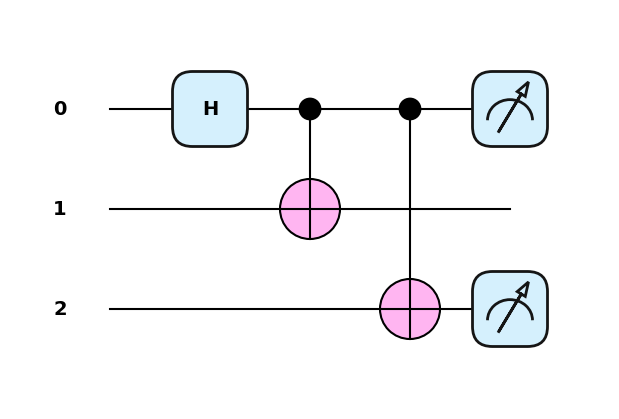

Estilo: black_white


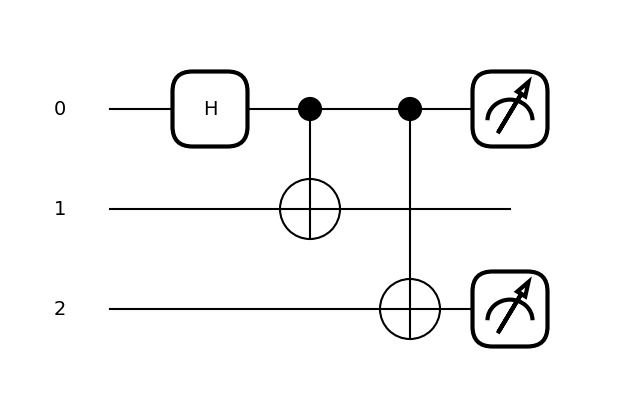

Estilo: black_white_dark


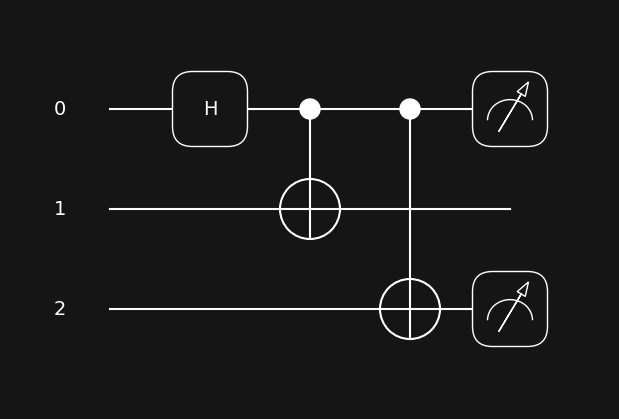

Estilo: sketch


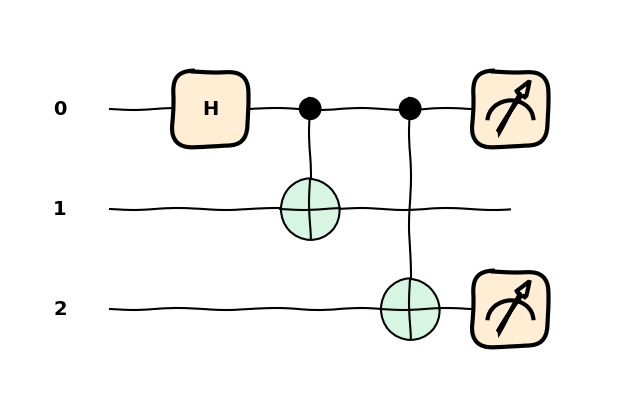

Estilo: default


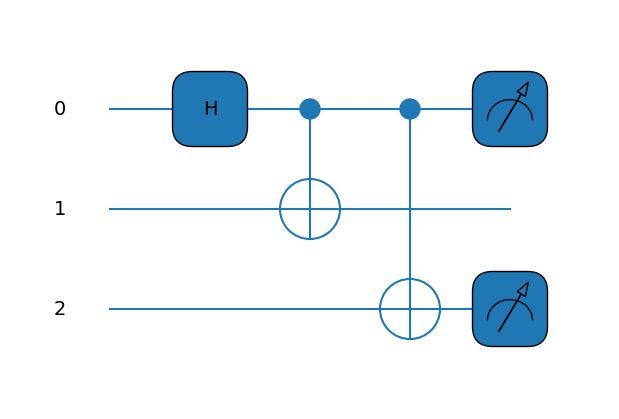

In [ ]:
# Algunos estilos disponibles para representar el circuito
styles = ["pennylane", "black_white", "black_white_dark", "sketch", "default"]

for style in styles:
    print(f"Estilo: {style}")

    qml.draw_mpl(circ, style=style)()
    plt.show()

# 3. Compuertas de Pauli

A continuación estudiaremos las compuertas de Pauli `X`, `Y` y `Z` utilizando PennyLane. Para cada una observaremos el circuito, el estado del qubit antes y después de aplicar la compuerta y su representación en la esfera de Bloch.

Como PennyLane no incluye una función equivalente a `plot_bloch_multivector` de Qiskit, definiremos una función auxiliar para visualizar estados de un qubit en la esfera de Bloch.

In [ ]:
# Función auxiliar para representar un estado de un qubit en la esfera de Bloch
def plot_bloch_state(state, title="Esfera de Bloch"):
    alpha, beta = state

    # Coordenadas del vector de Bloch
    x = 2 * np.real(np.conj(alpha) * beta)
    y = 2 * np.imag(np.conj(alpha) * beta)
    z = np.abs(alpha)**2 - np.abs(beta)**2

    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection="3d")

    # Esfera
    u = np.linspace(0, 2 * np.pi, 60)
    v = np.linspace(0, np.pi, 30)

    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(xs, ys, zs, linewidth=0.4, alpha=0.25)

    # Ejes
    ax.plot([-1, 1], [0, 0], [0, 0], alpha=0.4)
    ax.plot([0, 0], [-1, 1], [0, 0], alpha=0.4)
    ax.plot([0, 0], [0, 0], [-1, 1], alpha=0.4)

    # Vector de Bloch
    ax.quiver(0, 0, 0, x, y, z, arrow_length_ratio=0.12)

    ax.text(1.1, 0, 0, "x")
    ax.text(0, 1.1, 0, "y")
    ax.text(0, 0, 1.1, "|0⟩")
    ax.text(0, 0, -1.2, "|1⟩")

    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

    ax.set_box_aspect([1, 1, 1])
    ax.set_title(title)
    ax.set_axis_off()

    plt.show()

## 3.1 Compuerta X

Comenzaremos con la compuerta `X`. Crearemos un circuito de un qubit, obtendremos su estado inicial y posteriormente aplicaremos `qml.PauliX` sobre el qubit `0`.

In [ ]:
# Circuito que devuelve el estado inicial
@qml.qnode(dev)
def circ1_inicial():
    return qml.state()

# Circuito con la compuerta X
@qml.qnode(dev)
def circ1():
    qml.PauliX(wires=0)       # aplicar compuerta X al qubit 0
    return qml.state()

# Estados antes y después de X
psi_0 = circ1_inicial()
psi_1 = circ1()

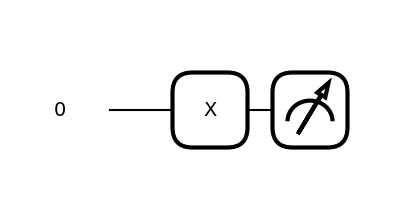

In [ ]:
# Mostrar el circuito
qml.draw_mpl(circ1)()
plt.show()

In [ ]:
print("👉 Estado inicial:")
print("➤ en forma de vector:")
print(psi_0)

print()
print("➤ en forma de ket:")
print("|0>")

print()

print("👉 Estado después de X:")
print("➤ en forma de vector:")
print(psi_1)

print()
print("➤ en forma de ket:")
print("|1>")

👉 Estado inicial:
➤ en forma de vector:
[1.+0.j 0.+0.j]

➤ en forma de ket:
|0>

👉 Estado después de X:
➤ en forma de vector:
[0.+0.j 1.+0.j]

➤ en forma de ket:
|1>


🔵 Estado inicial:


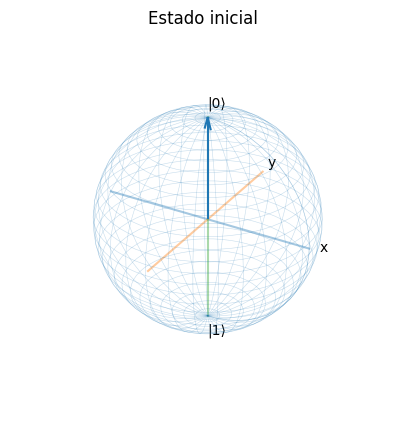

🔵 Estado después de X:


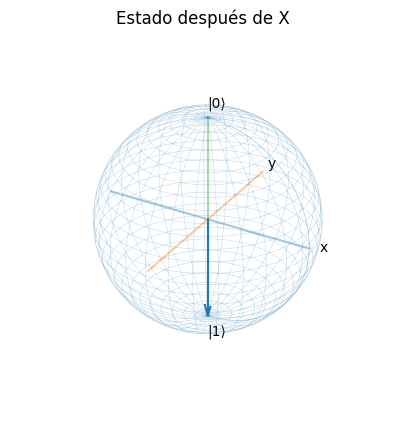

In [ ]:
print("🔵 Estado inicial:")
plot_bloch_state(psi_0, "Estado inicial")

print("🔵 Estado después de X:")
plot_bloch_state(psi_1, "Estado después de X")

## 3.2 Compuerta Y

Comenzaremos con la compuerta `Y`. Crearemos un circuito de un qubit, obtendremos su estado inicial y posteriormente aplicaremos `qml.PauliY` sobre el qubit `0`.

In [ ]:
# Circuito que devuelve el estado inicial
@qml.qnode(dev)
def circ2_inicial():
    return qml.state()

# Circuito con la compuerta Y
@qml.qnode(dev)
def circ2():
    qml.PauliY(wires=0)       # aplicar compuerta Y al qubit 0
    return qml.state()

# Estados antes y después de Y
psi_0 = circ2_inicial()
psi_1 = circ2()

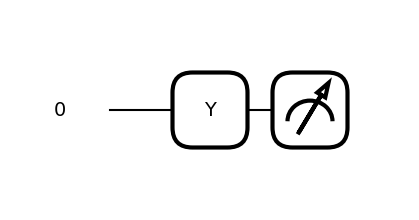

In [ ]:
# Mostrar el circuito
qml.draw_mpl(circ2)()
plt.show()

In [ ]:
print("👉 Estado inicial:")
print("➤ en forma de vector:")
print(psi_0)

print()
print("➤ en forma de ket:")
print("|0>")

print()

print("👉 Estado después de Y:")
print("➤ en forma de vector:")
print(psi_1)

print()
print("➤ en forma de ket:")
print("i|1>")

👉 Estado inicial:
➤ en forma de vector:
[1.+0.j 0.+0.j]

➤ en forma de ket:
|0>

👉 Estado después de Y:
➤ en forma de vector:
[0.+0.j 0.+1.j]

➤ en forma de ket:
i|1>


🔵 Estado inicial:


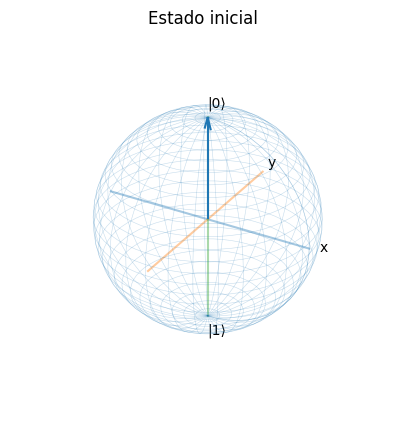

🔵 Estado después de Y:


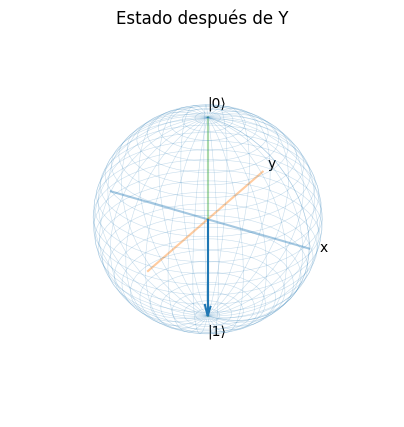

In [ ]:
print("🔵 Estado inicial:")
plot_bloch_state(psi_0, "Estado inicial")

print("🔵 Estado después de Y:")
plot_bloch_state(psi_1, "Estado después de Y")

## 3.3 Compuerta Z

Comenzaremos con la compuerta `Z`. Crearemos un circuito de un qubit, obtendremos su estado inicial y posteriormente aplicaremos `qml.PauliZ` sobre el qubit `0`.

In [ ]:
# Circuito que prepara el estado |1>
@qml.qnode(dev)
def circ3_inicial():
    qml.PauliX(wires=0)       # preparar el estado |1>
    return qml.state()

# Circuito que prepara |1> y aplica la compuerta Z
@qml.qnode(dev)
def circ3():
    qml.PauliX(wires=0)       # preparar el estado |1>
    qml.PauliZ(wires=0)       # aplicar compuerta Z al qubit 0
    return qml.state()

# Estados antes y después de Z
psi_0 = circ3_inicial()
psi_1 = circ3()

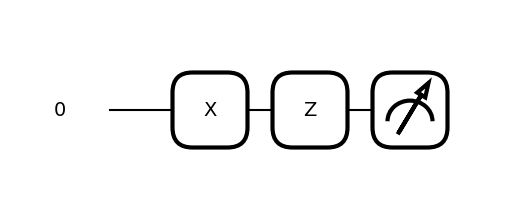

In [ ]:
# Mostrar el circuito
qml.draw_mpl(circ3)()
plt.show()

In [ ]:
print("👉 Estado inicial:")
print("➤ en forma de vector:")
print(psi_0)

print()
print("➤ en forma de ket:")
print("|1>")

print()

print("👉 Estado después de Z:")
print("➤ en forma de vector:")
print(psi_1)

print()
print("➤ en forma de ket:")
print("-|1>")

👉 Estado inicial:
➤ en forma de vector:
[0.+0.j 1.+0.j]

➤ en forma de ket:
|1>

👉 Estado después de Z:
➤ en forma de vector:
[ 0.+0.j -1.+0.j]

➤ en forma de ket:
-|1>


🔵 Estado inicial:


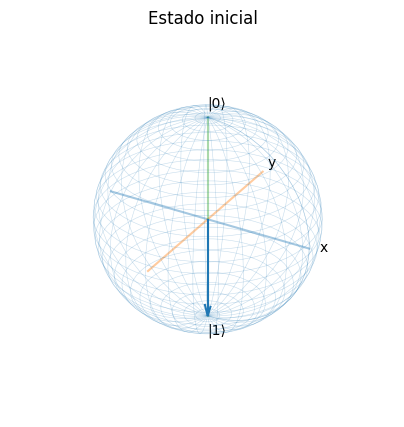

🔵 Estado después de Z:


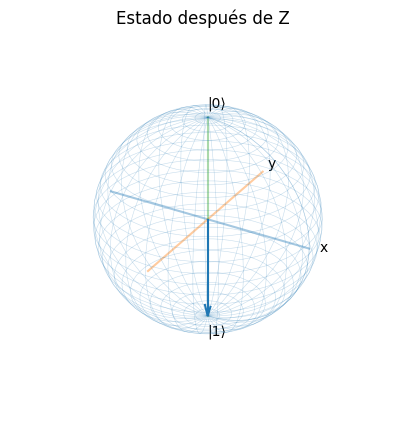

In [ ]:
print("🔵 Estado inicial:")
plot_bloch_state(psi_0, "Estado inicial")

print("🔵 Estado después de Z:")
plot_bloch_state(psi_1, "Estado después de Z")

# 4. Rotaciones con otros ángulos

Las compuertas de Pauli corresponden a rotaciones de $\pi$ radianes. En PennyLane también podemos realizar rotaciones con otros ángulos mediante `qml.RX`, `qml.RY` y `qml.RZ`.

En el siguiente ejemplo rotaremos el estado cuántico primero $\pi/2$ radianes alrededor del eje $y$, después $\pi/4$ radianes alrededor del eje $z$ y finalmente $\pi$ radianes alrededor del eje $x$.

Los estados intermedios son

$$
|\psi_0\rangle = |0\rangle
$$

$$
|\psi_1\rangle =
R_y\left(\frac{\pi}{2}\right)|\psi_0\rangle
$$

$$
|\psi_2\rangle =
R_z\left(\frac{\pi}{4}\right)|\psi_1\rangle
$$

$$
|\psi_3\rangle =
R_x(\pi)|\psi_2\rangle
$$

In [ ]:
# Estado inicial
@qml.qnode(dev)
def circ4_0():
    return qml.state()

# Primera rotación: pi/2 alrededor del eje y
@qml.qnode(dev)
def circ4_1():
    qml.RY(np.pi/2, wires=0)
    return qml.state()

# Segunda rotación: pi/4 alrededor del eje z
@qml.qnode(dev)
def circ4_2():
    qml.RY(np.pi/2, wires=0)
    qml.RZ(np.pi/4, wires=0)
    return qml.state()

# Tercera rotación: pi alrededor del eje x
@qml.qnode(dev)
def circ4():
    qml.RY(np.pi/2, wires=0)
    qml.RZ(np.pi/4, wires=0)
    qml.RX(np.pi, wires=0)
    return qml.state()

In [ ]:
# Obtenemos el estado después de cada etapa
psi_0 = circ4_0()
psi_1 = circ4_1()
psi_2 = circ4_2()
psi_3 = circ4()

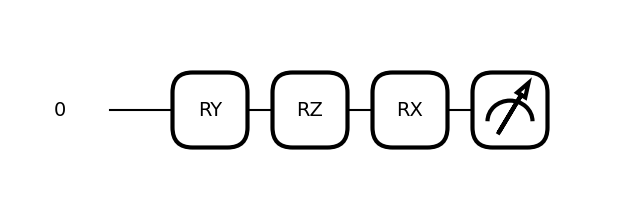

In [ ]:
# Mostrar el circuito completo
qml.draw_mpl(circ4)()
plt.show()

In [ ]:
print("👉 Estado inicial:")
print("➤ en forma de vector:")
print(psi_0)

print()

print("👉 Estado después de rotación de pi/2 alrededor del eje y:")
print("➤ en forma de vector:")
print(psi_1)

print()

print("👉 Estado después de rotación de pi/4 alrededor del eje z:")
print("➤ en forma de vector:")
print(psi_2)

print()

print("👉 Estado después de rotación de pi alrededor del eje x:")
print("➤ en forma de vector:")
print(psi_3)

👉 Estado inicial:
➤ en forma de vector:
[1.+0.j 0.+0.j]

👉 Estado después de rotación de pi/2 alrededor del eje y:
➤ en forma de vector:
[0.70710678+0.j 0.70710678+0.j]

👉 Estado después de rotación de pi/4 alrededor del eje z:
➤ en forma de vector:
[0.65328148-0.27059805j 0.65328148+0.27059805j]

👉 Estado después de rotación de pi alrededor del eje x:
➤ en forma de vector:
[ 0.27059805-0.65328148j -0.27059805-0.65328148j]


🔵 Estado inicial:


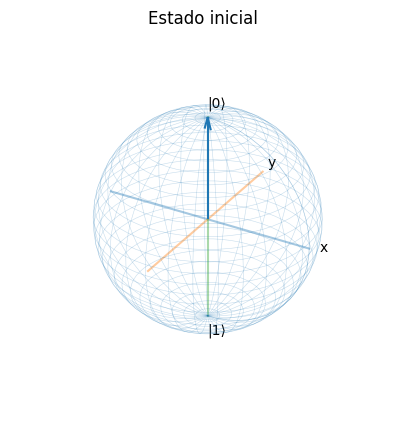

🔵 Estado después de rotación de pi/2 alrededor del eje y:


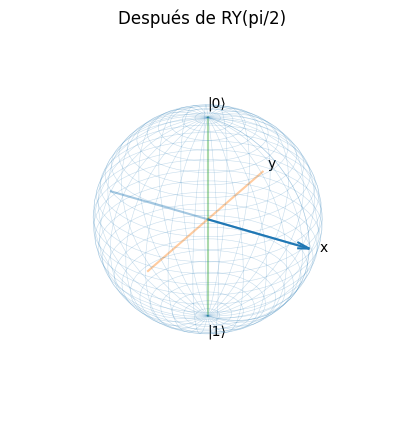

🔵 Estado después de rotación de pi/4 alrededor del eje z:


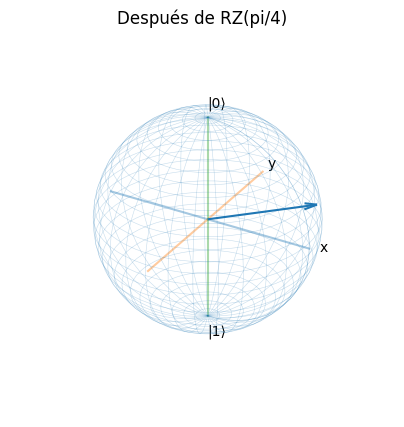

🔵 Estado después de rotación de pi alrededor del eje x:


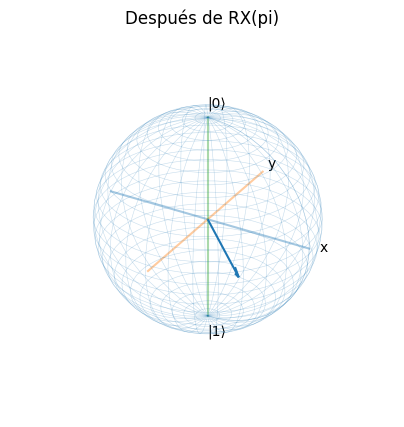

In [ ]:
print("🔵 Estado inicial:")
plot_bloch_state(psi_0, "Estado inicial")

print("🔵 Estado después de rotación de pi/2 alrededor del eje y:")
plot_bloch_state(
    psi_1,
    "Después de RY(pi/2)"
)

print("🔵 Estado después de rotación de pi/4 alrededor del eje z:")
plot_bloch_state(
    psi_2,
    "Después de RZ(pi/4)"
)

print("🔵 Estado después de rotación de pi alrededor del eje x:")
plot_bloch_state(
    psi_3,
    "Después de RX(pi)"
)

# 5. Compuerta Hadamard

Comenzaremos con la compuerta Hadamard. Partiremos del estado $|0\rangle$, aplicaremos `qml.Hadamard` para obtener el estado $|+\rangle$, posteriormente aplicaremos `qml.PauliZ` para obtener $|-\rangle$ y finalmente aplicaremos nuevamente `qml.Hadamard` para obtener el estado $|1\rangle$.

In [ ]:
# Estado inicial
@qml.qnode(dev)
def circ5_0():
    return qml.state()

# Primera compuerta H: |0> -> |+>
@qml.qnode(dev)
def circ5_1():
    qml.Hadamard(wires=0)
    return qml.state()

# Aplicamos H y después Z: |0> -> |+> -> |->
@qml.qnode(dev)
def circ5_2():
    qml.Hadamard(wires=0)
    qml.PauliZ(wires=0)
    return qml.state()

# Aplicamos H, Z y H: |0> -> |+> -> |-> -> |1>
@qml.qnode(dev)
def circ5():
    qml.Hadamard(wires=0)
    qml.PauliZ(wires=0)
    qml.Hadamard(wires=0)
    return qml.state()

In [ ]:
# Obtenemos el estado después de cada etapa
psi_0 = circ5_0()
psi_1 = circ5_1()
psi_2 = circ5_2()
psi_3 = circ5()

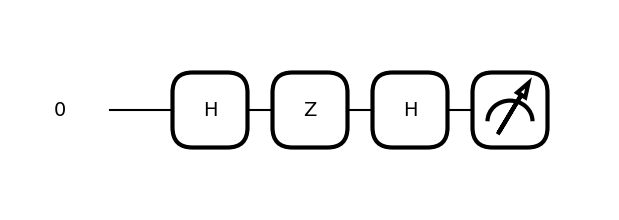

In [ ]:
# Mostrar el circuito completo
qml.draw_mpl(circ5)()
plt.show()

In [ ]:
print("👉 Estado inicial:")
print("➤ en forma de vector:")
print(psi_0)

print()
print("➤ en forma de ket:")
print("|0>")

print()

print("👉 Estado después de la primera H:")
print("➤ en forma de vector:")
print(psi_1)

print()
print("➤ en forma de ket:")
print("|+>")

print()

print("👉 Estado después de Z:")
print("➤ en forma de vector:")
print(psi_2)

print()
print("➤ en forma de ket:")
print("|->")

print()

print("👉 Estado después de la segunda H:")
print("➤ en forma de vector:")
print(psi_3)

print()
print("➤ en forma de ket:")
print("|1>")

👉 Estado inicial:
➤ en forma de vector:
[1.+0.j 0.+0.j]

➤ en forma de ket:
|0>

👉 Estado después de la primera H:
➤ en forma de vector:
[0.70710678+0.j 0.70710678+0.j]

➤ en forma de ket:
|+>

👉 Estado después de Z:
➤ en forma de vector:
[ 0.70710678+0.j -0.70710678+0.j]

➤ en forma de ket:
|->

👉 Estado después de la segunda H:
➤ en forma de vector:
[0.+0.j 1.+0.j]

➤ en forma de ket:
|1>


🔵 Estado inicial:


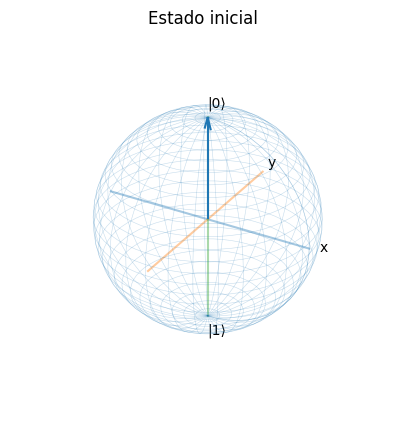

🔵 Estado después de la primera H:


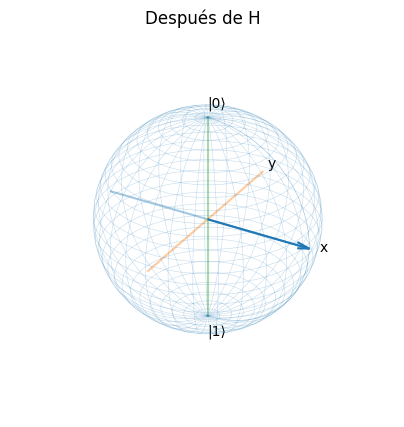

🔵 Estado después de Z:


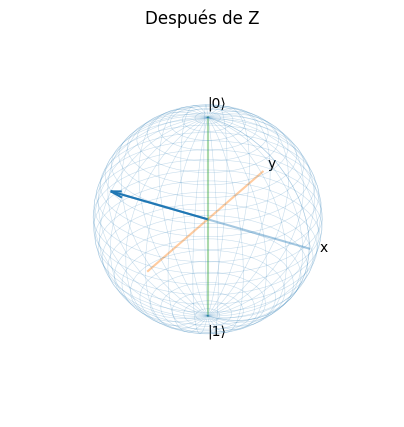

🔵 Estado después de la segunda H:


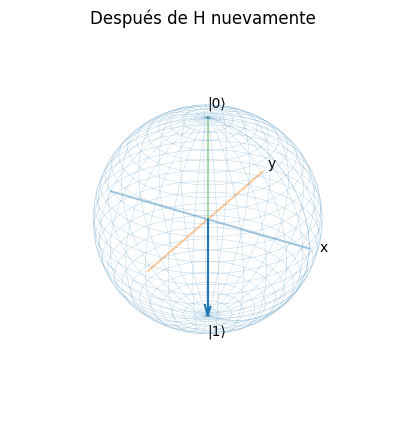

In [ ]:
print("🔵 Estado inicial:")
plot_bloch_state(psi_0, "Estado inicial")

print("🔵 Estado después de la primera H:")
plot_bloch_state(
    psi_1,
    "Después de H"
)

print("🔵 Estado después de Z:")
plot_bloch_state(
    psi_2,
    "Después de Z"
)

print("🔵 Estado después de la segunda H:")
plot_bloch_state(
    psi_3,
    "Después de H nuevamente"
)

## 6. Compuertas de cambio de fase

En PennyLane podemos aplicar distintas compuertas que modifican la fase de un estado cuántico. Entre ellas se encuentran las compuertas `S`, `T` y `PhaseShift`.

Para observar su efecto en la esfera de Bloch, comenzaremos preparando el estado $|+\rangle$ mediante una compuerta de Hadamard. Posteriormente aplicaremos de manera sucesiva las compuertas `S`, `T†` y una compuerta de fase con $\phi=2\pi/3$.

In [ ]:
dev = qml.device("default.qubit", wires=1)

# Estado inicial |+>
@qml.qnode(dev)
def circuito_inicial():
    qml.Hadamard(wires=0)
    return qml.state()

# Estado después de S
@qml.qnode(dev)
def circuito_s():
    qml.Hadamard(wires=0)
    qml.S(wires=0)
    return qml.state()

# Estado después de T†
@qml.qnode(dev)
def circuito_t_dagger():
    qml.Hadamard(wires=0)
    qml.S(wires=0)
    qml.adjoint(qml.T)(wires=0)
    return qml.state()

# Estado después de PhaseShift(2π/3)
@qml.qnode(dev)
def circuito_phase():
    qml.Hadamard(wires=0)
    qml.S(wires=0)
    qml.adjoint(qml.T)(wires=0)
    qml.PhaseShift(2 * np.pi / 3, wires=0)
    return qml.state()


psi_0 = circuito_inicial()
psi_1 = circuito_s()
psi_2 = circuito_t_dagger()
psi_3 = circuito_phase()

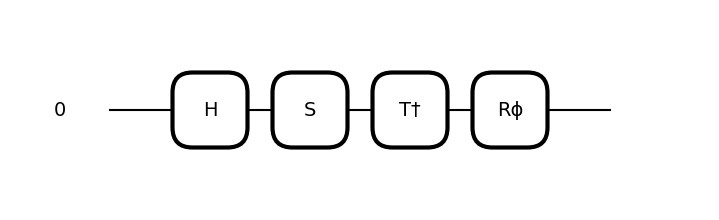

In [ ]:
def circuito_completo():
    qml.Hadamard(wires=0)
    qml.S(wires=0)
    qml.adjoint(qml.T)(wires=0)
    qml.PhaseShift(2 * np.pi / 3, wires=0)

qml.draw_mpl(circuito_completo)();

In [ ]:
print("👉 Estado inicial |+>:")
print(psi_0)
print()

print("👉 Estado después de S:")
print(psi_1)
print()

print("👉 Estado después de T†:")
print(psi_2)
print()

print("👉 Estado después de PhaseShift(2π/3):")
print(psi_3)

👉 Estado inicial |+>:
[0.70710678+0.j 0.70710678+0.j]

👉 Estado después de S:
[0.70710678+0.j         0.        +0.70710678j]

👉 Estado después de T†:
[0.70710678+0.j  0.5       +0.5j]

👉 Estado después de PhaseShift(2π/3):
[ 0.70710678+0.j        -0.6830127 +0.1830127j]


🔵 Estado inicial |+>:


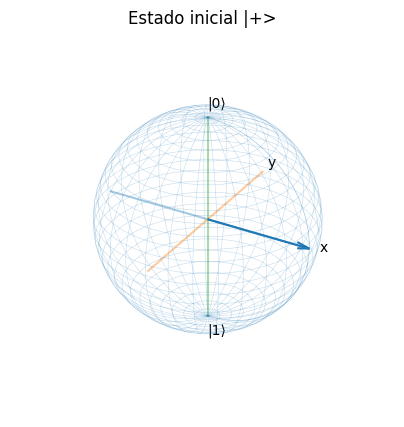

🔵 Estado después de S:


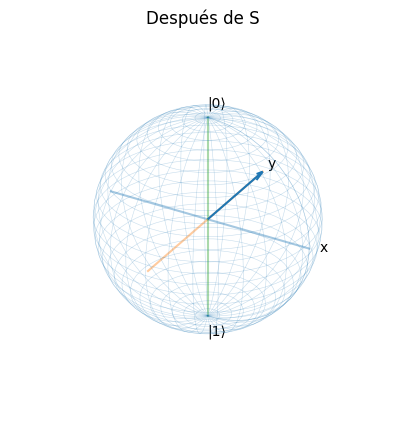

🔵 Estado después de T†:


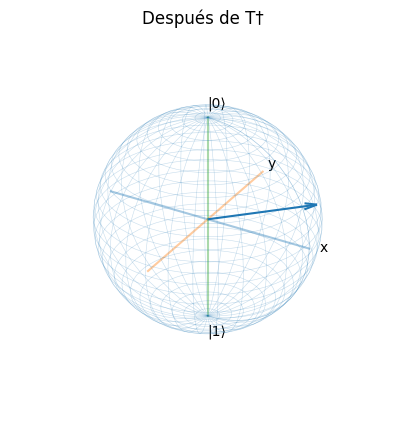

🔵 Estado después de P(2π/3):


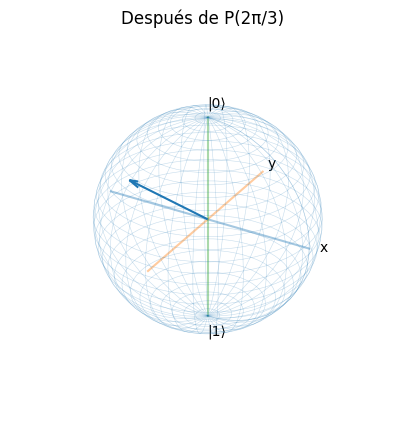

In [ ]:
print("🔵 Estado inicial |+>:")
plot_bloch_state(
    psi_0,
    "Estado inicial |+>"
)

print("🔵 Estado después de S:")
plot_bloch_state(
    psi_1,
    "Después de S"
)

print("🔵 Estado después de T†:")
plot_bloch_state(
    psi_2,
    "Después de T†"
)

print("🔵 Estado después de P(2π/3):")
plot_bloch_state(
    psi_3,
    "Después de P(2π/3)"
)

### 7. Compuerta general de un qubit

La compuerta `U` permite representar una transformación general sobre un solo qubit mediante tres parámetros. En PennyLane se implementa mediante `qml.U3(θ, ϕ, λ)`.

A continuación, aplicaremos la compuerta `U3` sobre el estado inicial $|0\rangle$ utilizando los parámetros $\theta=\pi/3$, $\phi=\pi/2$ y $\lambda=\pi/5$. Posteriormente observaremos el cambio producido en el estado y en su representación sobre la esfera de Bloch.

In [ ]:
# Parámetros de la compuerta U3
theta = np.pi / 3
phi = np.pi / 2
lam = np.pi / 5

dev = qml.device("default.qubit", wires=1)

# Estado inicial
@qml.qnode(dev)
def circuito_inicial():
    return qml.state()

# Estado después de aplicar U3
@qml.qnode(dev)
def circuito_u3():
    qml.U3(theta, phi, lam, wires=0)
    return qml.state()

psi_0 = circuito_inicial()
psi_1 = circuito_u3()

print("👉 Estado inicial:")
print(psi_0)
print()

print("👉 Estado después de U3(pi/3, pi/2, pi/5):")
print(psi_1)

👉 Estado inicial:
[1.+0.j 0.+0.j]

👉 Estado después de U3(pi/3, pi/2, pi/5):
[8.66025404e-01+0.j  3.06161700e-17+0.5j]


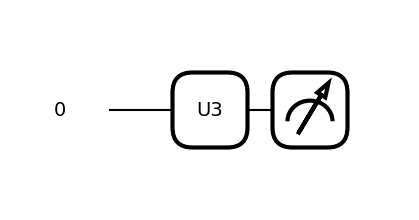

In [ ]:
@qml.qnode(dev)
def circuito_u3_dibujo():
    qml.U3(theta, phi, lam, wires=0)
    return qml.state()

fig, ax = qml.draw_mpl(circuito_u3_dibujo)()
plt.show()

🔵 Estado inicial:


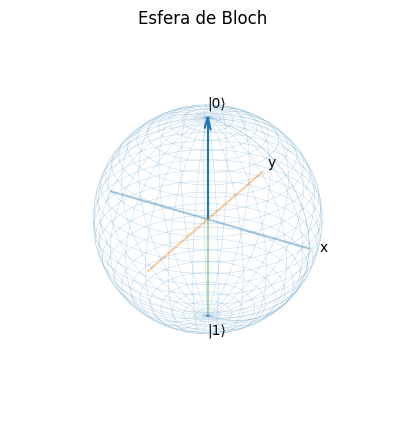

🔵 Estado después de U3(pi/3, pi/2, pi/5):


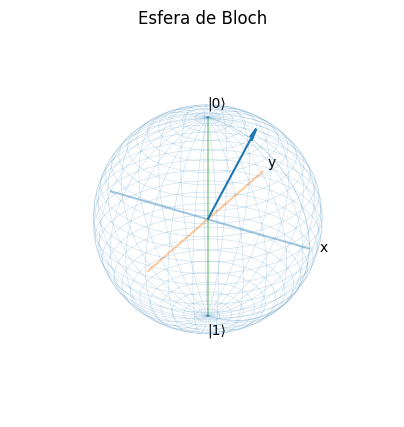

In [ ]:
print("🔵 Estado inicial:")
plot_bloch_state(psi_0)

print("🔵 Estado después de U3(pi/3, pi/2, pi/5):")
plot_bloch_state(psi_1)